# Superligaen Run-In — Informative Prior Model

Two-stage approach:
1. Train on **2024/25** to get posterior team strengths as priors
2. Promoted teams (Fredericia, OB) get **flat priors**
3. Use these priors in the **2025/26** model for ratings + run-in simulation

In [1]:
import sys, os
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import poisson
import requests, time
from collections import defaultdict

# ── Path resolution ────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = NOTEBOOK_DIR.parents[1]  # analysis/superliga-run-in → repo root
NP_BAYES_DIR = str(REPO_ROOT / 'algo' / 'models' / 'team_strength' / 'non_penalty_bayes')
sys.path.insert(0, NP_BAYES_DIR)
sys.path.insert(0, str(REPO_ROOT))

from src.data_utils import load_and_process_data
from src.superliga_model import build_and_sample_model
from src.simulation import load_actual_results, run_multiple_seasons

DB_PATH = str(REPO_ROOT / 'infra' / 'data' / 'db' / 'fotmob.db')

LEAGUE = 'Superligaen'

# Model hyperparams (same as outputs.ipynb)
DECAY_RATE   = 0.0018
GOALS_WEIGHT = 0.35
XG_WEIGHT    = 0.50
PSXG_WEIGHT  = 0.15
EPV_WEIGHT   = 0.0
N_SAMPLES    = 10_000
N_TUNE       = 5_000

BASELINE_HOME_PENS = 0.18 * 0.78
BASELINE_AWAY_PENS = 0.13 * 0.78

# Teams promoted into 2025/26 (not in 2024/25) → flat priors
PROMOTED_TEAMS = {'Fredericia', 'OB'}

# Wide sigma for all teams: keeps the 2024/25 mean as a soft nudge
# but lets 2025/26 data largely determine the posterior.
# Same width as the flat prior so the prior-season signal is mild.
INFORMATIVE_PRIOR_SIGMA = 0.5

print(f'REPO: {REPO_ROOT}')
print(f'DB:   {DB_PATH}')

REPO: /Users/admin/dev/algobetting
DB:   /Users/admin/dev/algobetting/infra/data/db/fotmob.db


## Step 1 — Train on 2024/25 to extract prior strengths

In [2]:
df_prior, tm_prior, n_prior = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season='2024-2025',
    decay_rate=DECAY_RATE,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
print(f'2024/25: {n_prior} teams, {df_prior["match_id"].nunique()} matches')
print('Teams:', sorted(tm_prior.keys()))

_, trace_prior = build_and_sample_model(
    df_prior, n_prior, trace=N_SAMPLES, tune=N_TUNE, team_mapping=tm_prior,
)
print('2024/25 model done.')

2024/25: 10 teams, 133 matches
Teams: ['AGF', 'Brøndby IF', 'FC København', 'FC Midtjylland', 'Nordsjælland', 'Randers FC', 'Silkeborg', 'Sønderjyske', 'Vejle Boldklub', 'Viborg']
2024/25 model done.


## Step 2 — Extract 2024/25 posteriors as priors for 2025/26

Use posterior mean ± sd of `att_str` / `def_str` per team.
Promoted teams (Fredericia, OB) get flat priors `N(0, 0.5)`.

In [3]:
post_prior = trace_prior.posterior
team_names_prior = list(tm_prior.keys())
n_prior_teams    = len(team_names_prior)

att_post = post_prior['att_str'].values.reshape(-1, n_prior_teams)
def_post = post_prior['def_str'].values.reshape(-1, n_prior_teams)

prior_strengths = pd.DataFrame({
    'team':    team_names_prior,
    'att_mu':  att_post.mean(axis=0),
    'att_sd':  att_post.std(axis=0),
    'def_mu':  def_post.mean(axis=0),
    'def_sd':  def_post.std(axis=0),
}).sort_values('att_mu', ascending=False).reset_index(drop=True)

prior_strengths = prior_strengths.round(3)
print('2024/25 posterior strengths (used as priors for 2025/26):')
prior_strengths

2024/25 posterior strengths (used as priors for 2025/26):


,team,att_mu,att_sd,def_mu,def_sd
0,FC Midtjylland,0.131,0.152,-0.031,0.161
1,FC København,0.103,0.155,-0.339,0.184
2,Brøndby IF,0.075,0.161,-0.151,0.171
3,Nordsjælland,0.060,0.167,-0.000,0.159
4,AGF,0.050,0.160,-0.062,0.162
5,Viborg,0.046,0.177,0.145,0.176
6,Randers FC,0.037,0.164,-0.008,0.160
7,Silkeborg,-0.047,0.170,-0.117,0.182
8,Sønderjyske,-0.193,0.186,0.296,0.156
9,Vejle Boldklub,-0.262,0.189,0.267,0.156


## Step 3 — Train 2025/26 model with informative priors

In [4]:
df_curr, tm_curr, n_curr = load_and_process_data(
    db_path=DB_PATH, league=LEAGUE, season='2025-2026',
    decay_rate=DECAY_RATE,
    goals_weight=GOALS_WEIGHT, xg_weight=XG_WEIGHT,
    psxg_weight=PSXG_WEIGHT, epv_weight=EPV_WEIGHT,
)
print(f'2025/26: {n_curr} teams, {df_curr["match_id"].nunique()} matches')

# Build prior dicts — use 2024/25 posterior mean as mu, but wide fixed sigma
# so the current season's data is free to move things substantially.
strengths_by_name = prior_strengths.set_index('team')

manual_att_priors = {}
manual_def_priors = {}

for team in tm_curr.keys():
    if team in PROMOTED_TEAMS or team not in strengths_by_name.index:
        manual_att_priors[team] = (0.0, INFORMATIVE_PRIOR_SIGMA)
        manual_def_priors[team] = (0.0, INFORMATIVE_PRIOR_SIGMA)
    else:
        manual_att_priors[team] = (float(strengths_by_name.loc[team, 'att_mu']), INFORMATIVE_PRIOR_SIGMA)
        manual_def_priors[team] = (float(strengths_by_name.loc[team, 'def_mu']), INFORMATIVE_PRIOR_SIGMA)

print('Prior assignments:')
for t in sorted(tm_curr.keys()):
    label = 'FLAT (promoted)' if t in PROMOTED_TEAMS else 'informative'
    print(f'  {t:20s}  att_mu={manual_att_priors[t][0]:+.3f}  sigma={INFORMATIVE_PRIOR_SIGMA}  [{label}]')

2025/26: 12 teams, 165 matches
Prior assignments:
  AGF                   att_mu=+0.050  sigma=0.5  [informative]
  Brøndby IF            att_mu=+0.075  sigma=0.5  [informative]
  FC København          att_mu=+0.103  sigma=0.5  [informative]
  FC Midtjylland        att_mu=+0.131  sigma=0.5  [informative]
  Fredericia            att_mu=+0.000  sigma=0.5  [FLAT (promoted)]
  Nordsjælland          att_mu=+0.060  sigma=0.5  [informative]
  OB                    att_mu=+0.000  sigma=0.5  [FLAT (promoted)]
  Randers FC            att_mu=+0.037  sigma=0.5  [informative]
  Silkeborg             att_mu=-0.047  sigma=0.5  [informative]
  Sønderjyske           att_mu=-0.193  sigma=0.5  [informative]
  Vejle Boldklub        att_mu=-0.262  sigma=0.5  [informative]
  Viborg                att_mu=+0.046  sigma=0.5  [informative]


In [5]:
_, trace = build_and_sample_model(
    df_curr, n_curr,
    trace=N_SAMPLES, tune=N_TUNE,
    team_mapping=tm_curr,
    manual_att_priors=manual_att_priors,
    manual_def_priors=manual_def_priors,
)
team_mapping = tm_curr
n_teams = n_curr
team_names = list(team_mapping.keys())
print('2025/26 model done.')

2025/26 model done.


## Strength Ratings

In [6]:
posterior  = trace.posterior

att  = posterior['att_str'].values.reshape(-1, n_teams)
defn = posterior['def_str'].values.reshape(-1, n_teams)
hadv = posterior['home_adv'].values.reshape(-1)
base = posterior['baseline'].values.reshape(-1)

ratings = pd.DataFrame({
    'team':     team_names,
    'att_mean': att.mean(axis=0).round(3),
    'att_sd':   att.std(axis=0).round(3),
    'att_lo':   np.percentile(att, 5,  axis=0).round(3),
    'att_hi':   np.percentile(att, 95, axis=0).round(3),
    'def_mean': defn.mean(axis=0).round(3),
    'def_sd':   defn.std(axis=0).round(3),
    'def_lo':   np.percentile(defn, 5,  axis=0).round(3),
    'def_hi':   np.percentile(defn, 95, axis=0).round(3),
})

ratings['net'] = (ratings['att_mean'] - ratings['def_mean']).round(3)
ratings = ratings.sort_values('net', ascending=False).reset_index(drop=True)
ratings

,team,att_mean,att_sd,att_lo,att_hi,def_mean,def_sd,def_lo,def_hi,net
0,AGF,0.210,0.155,-0.055,0.455,-0.312,0.193,-0.629,0.005,0.522
1,FC Midtjylland,0.293,0.149,0.043,0.534,-0.209,0.183,-0.518,0.081,0.502
2,Brøndby IF,0.044,0.160,-0.218,0.306,-0.300,0.181,-0.600,-0.008,0.344
3,FC København,0.170,0.155,-0.091,0.419,-0.109,0.176,-0.402,0.178,0.279
4,Viborg,0.058,0.167,-0.220,0.329,-0.013,0.163,-0.290,0.247,0.071
5,Nordsjælland,0.097,0.163,-0.175,0.352,0.031,0.161,-0.235,0.285,0.066
6,OB,0.018,0.163,-0.256,0.279,0.141,0.156,-0.121,0.401,-0.123
7,Randers FC,-0.196,0.169,-0.484,0.072,-0.064,0.169,-0.353,0.201,-0.132
8,Sønderjyske,-0.077,0.178,-0.371,0.209,0.070,0.160,-0.200,0.324,-0.147
9,Fredericia,-0.105,0.172,-0.396,0.179,0.313,0.150,0.063,0.556,-0.418


In [7]:
n_samp   = 10_000
idx      = np.random.choice(len(base), size=n_samp, replace=True)
team_idx = {name: i for i, name in enumerate(team_names)}

rows = []
for team in team_names:
    ti = team_idx[team]
    rows.append({
        'team':        team,
        'xg_home_for': round(np.exp(base[idx] + att[idx, ti] + hadv[idx]).mean(), 3),
        'xg_home_ag':  round(np.exp(base[idx] + defn[idx, ti]).mean(), 3),
        'xg_away_for': round(np.exp(base[idx] + att[idx, ti]).mean(), 3),
        'xg_away_ag':  round(np.exp(base[idx] + defn[idx, ti] + hadv[idx]).mean(), 3),
    })

xg_table = pd.DataFrame(rows)
xg_table['xg_diff'] = (
    xg_table['xg_home_for'] + xg_table['xg_away_for'] -
    xg_table['xg_home_ag']  - xg_table['xg_away_ag']
).round(3)
xg_table.sort_values('xg_diff', ascending=False).reset_index(drop=True)

,team,xg_home_for,xg_home_ag,xg_away_for,xg_away_ag,xg_diff
0,FC Midtjylland,1.946,1.042,1.716,1.182,1.438
1,AGF,1.786,0.945,1.574,1.071,1.344
2,Brøndby IF,1.524,0.953,1.344,1.080,0.835
3,FC København,1.721,1.150,1.518,1.304,0.785
4,Viborg,1.542,1.263,1.358,1.433,0.204
5,Nordsjælland,1.596,1.321,1.407,1.499,0.183
6,Randers FC,1.198,1.205,1.056,1.367,-0.318
7,OB,1.478,1.470,1.303,1.667,-0.356
8,Sønderjyske,1.347,1.373,1.188,1.557,-0.395
9,Silkeborg,1.167,1.616,1.029,1.834,-1.254


## Remaining Fixtures & Predictions

In [8]:
import sqlite3 as _sq

_SPORTSDB_TO_MODEL = {
    'AGF Aarhus':       'AGF',
    'Brøndby':          'Brøndby IF',
    'FC Copenhagen':    'FC København',
    'FC Midtjylland':   'FC Midtjylland',
    'Fredericia':       'Fredericia',
    'FC Nordsjælland':  'Nordsjælland',
    'Odense BK':        'OB',
    'Randers FC':       'Randers FC',
    'Silkeborg IF':     'Silkeborg',
    'Sønderjyske':      'Sønderjyske',
    'Vejle':            'Vejle Boldklub',
    'Viborg':           'Viborg',
}

_SPORTSDB_ID = '4340'
_SEASON      = '2025-2026'

def _get_all_remaining_fixtures(start_round=1, end_round=40):
    fixtures = []
    for rnd in range(start_round, end_round + 1):
        try:
            r = requests.get(
                f'https://www.thesportsdb.com/api/v1/json/3/eventsround.php'
                f'?id={_SPORTSDB_ID}&r={rnd}&s={_SEASON}',
                timeout=10,
            )
            events = r.json().get('events') or []
            time.sleep(0.5)
        except Exception:
            continue
        for e in events:
            if e.get('intHomeScore') is None:
                home = _SPORTSDB_TO_MODEL.get(e['strHomeTeam'], e['strHomeTeam'])
                away = _SPORTSDB_TO_MODEL.get(e['strAwayTeam'], e['strAwayTeam'])
                fixtures.append({
                    'date': e['dateEvent'],
                    'time': (e.get('strTime') or '')[:5],
                    'gw':   e['intRound'],
                    'home': home,
                    'away': away,
                })
    return sorted(fixtures, key=lambda x: (x['date'], x['time']))

_conn_r = _sq.connect(DB_PATH)
_max_round = _conn_r.execute(
    "SELECT MAX(CAST(round AS INTEGER)) FROM matches "
    "WHERE league_id=? AND season=? AND home_goals IS NOT NULL",
    [LEAGUE, '2025-2026']
).fetchone()[0] or 1
_conn_r.close()
_start_round = max(1, _max_round)
print(f'Fetching from round {_start_round} onwards')

remaining_fixtures = _get_all_remaining_fixtures(start_round=_start_round)
print(f'Fetched {len(remaining_fixtures)} remaining fixtures')

unknown = {f['home'] for f in remaining_fixtures if f['home'] not in team_mapping} | \
          {f['away'] for f in remaining_fixtures if f['away'] not in team_mapping}
if unknown:
    print(f'WARNING — unknown teams: {unknown}')
remaining_fixtures[:10]

Fetching from round 28 onwards
Fetched 27 remaining fixtures


[{'date': '2026-04-23',
  'time': '16:00',
  'gw': '28',
  'home': 'Randers FC',
  'away': 'Fredericia'},
 {'date': '2026-04-23',
  'time': '16:00',
  'gw': '28',
  'home': 'Nordsjælland',
  'away': 'AGF'},
 {'date': '2026-04-23',
  'time': '18:00',
  'gw': '28',
  'home': 'Sønderjyske',
  'away': 'FC Midtjylland'},
 {'date': '2026-04-26',
  'time': '12:00',
  'gw': '29',
  'home': 'Fredericia',
  'away': 'OB'},
 {'date': '2026-04-26',
  'time': '12:00',
  'gw': '29',
  'home': 'Silkeborg',
  'away': 'Randers FC'},
 {'date': '2026-04-26',
  'time': '14:00',
  'gw': '29',
  'home': 'Sønderjyske',
  'away': 'Brøndby IF'},
 {'date': '2026-04-26',
  'time': '16:00',
  'gw': '29',
  'home': 'Viborg',
  'away': 'Nordsjælland'},
 {'date': '2026-04-26',
  'time': '18:00',
  'gw': '29',
  'home': 'AGF',
  'away': 'FC Midtjylland'},
 {'date': '2026-04-27',
  'time': '17:00',
  'gw': '29',
  'home': 'FC København',
  'away': 'Vejle Boldklub'},
 {'date': '2026-05-01',
  'time': '17:00',
  'gw': '3

In [9]:
_att  = posterior['att_str'].values.reshape(-1, n_teams)
_defn = posterior['def_str'].values.reshape(-1, n_teams)
_hadv = posterior['home_adv'].values.reshape(-1)
_base = posterior['baseline'].values.reshape(-1)
_rng  = np.random.choice(len(_base), size=2000, replace=True)

def _predict(home_team, away_team):
    hi = team_mapping[home_team]
    ai = team_mapping[away_team]
    home_lam = np.mean(np.exp(_base[_rng] + _hadv[_rng] + _att[_rng, hi] + _defn[_rng, ai])) + BASELINE_HOME_PENS
    away_lam = np.mean(np.exp(_base[_rng] + _att[_rng, ai] + _defn[_rng, hi])) + BASELINE_AWAY_PENS
    return home_lam, away_lam

def _match_probs(home_lam, away_lam, max_goals=10):
    h = np.array([poisson.pmf(g, home_lam) for g in range(max_goals + 1)])
    a = np.array([poisson.pmf(g, away_lam) for g in range(max_goals + 1)])
    grid = np.outer(h, a)
    return float(np.tril(grid, -1).sum()), float(np.trace(grid)), float(np.triu(grid, 1).sum())

rows = []
for f in remaining_fixtures:
    if f['home'] not in team_mapping or f['away'] not in team_mapping:
        continue
    hl, al = _predict(f['home'], f['away'])
    w, d, l = _match_probs(hl, al)
    rows.append({
        'GW':      f['gw'],
        'Date':    f['date'],
        'Time':    f['time'],
        'Home':    f['home'],
        'Away':    f['away'],
        'Home xG': round(hl, 2),
        'Away xG': round(al, 2),
        'Home W%': round(w * 100, 1),
        'Draw%':   round(d * 100, 1),
        'Away W%': round(l * 100, 1),
    })

_PRED_COLS = ['GW','Date','Time','Home','Away','Home xG','Away xG','Home W%','Draw%','Away W%']
pred_df = pd.DataFrame(rows, columns=_PRED_COLS) if rows else pd.DataFrame(columns=_PRED_COLS)
pred_df

,GW,Date,Time,Home,Away,Home xG,Away xG,Home W%,Draw%,Away W%
0,28,2026-04-23,16:00,Randers FC,Fredericia,1.79,1.19,51.4,23.2,25.4
1,28,2026-04-23,16:00,Nordsjælland,AGF,1.33,1.75,29.3,23.4,47.4
2,28,2026-04-23,18:00,Sønderjyske,FC Midtjylland,1.26,1.97,24.3,21.9,53.9
3,29,2026-04-26,12:00,Fredericia,OB,1.65,1.92,33.5,21.8,44.7
4,29,2026-04-26,12:00,Silkeborg,Randers FC,1.25,1.44,32.7,25.8,41.5
5,29,2026-04-26,14:00,Sønderjyske,Brøndby IF,1.15,1.58,27.8,25.0,47.2
6,29,2026-04-26,16:00,Viborg,Nordsjælland,1.76,1.51,43.8,23.0,33.2
7,29,2026-04-26,18:00,AGF,FC Midtjylland,1.63,1.38,43.5,24.1,32.5
8,29,2026-04-27,17:00,FC København,Vejle Boldklub,2.28,0.98,66.7,18.5,14.7
9,30,2026-05-01,17:00,Brøndby IF,Nordsjælland,1.74,1.15,51.2,23.6,25.2


## Season Simulation

In [10]:
N_SIMS    = 10_000
df_actual = load_actual_results(DB_PATH, LEAGUE, '2025-2026')
print(f'Actual matches: {len(df_actual)}')

avg_table, position_freq = run_multiple_seasons(
    N_SIMS, trace, team_mapping, df_actual,
    remaining_fixtures=remaining_fixtures,
)

# Current actual points
_teams = list(team_mapping.keys())
_pts   = {t: 0 for t in _teams}
_gd    = {t: 0 for t in _teams}

for _, r in df_actual[df_actual['home_goals'].notna()].iterrows():
    h, a = r['home_team'], r['away_team']
    if h not in _pts or a not in _pts:
        continue
    hg, ag = int(r['home_goals']), int(r['away_goals'])
    _gd[h] += hg - ag;  _gd[a] += ag - hg
    if   hg > ag: _pts[h] += 3
    elif ag > hg: _pts[a] += 3
    else:         _pts[h] += 1; _pts[a] += 1

avg_table = avg_table.merge(
    pd.DataFrame({'team': list(_pts.keys()), 'current_pts': list(_pts.values())}),
    on='team',
)
avg_table

Actual matches: 165
Pre-computing xG for 132 unique pairs...
  Played: 165   To simulate: 27
Running 10,000 simulations...
  2,000 / 10,000
  4,000 / 10,000
  6,000 / 10,000
  8,000 / 10,000


,team,avg_points,pts_low,pts_high,avg_wins,avg_draws,avg_losses,avg_goals_for,avg_goals_against,avg_xg_for,avg_xg_against,avg_position,title_pct,top5_pct,top8_pct,relegation_pct,avg_goal_difference,avg_xg_difference,current_pts
0,AGF,64.5581,60.858075,68.258125,18.4606,9.1763,4.3631,59.5543,33.9852,58.297221,36.718623,1.3473,65.3,100.0,100.0,0.0,25.5691,21.578599,56
1,FC Midtjylland,62.2881,58.549821,66.026379,17.3797,10.1490,4.4713,73.8103,35.6426,62.437227,39.798004,1.6539,34.7,100.0,100.0,0.0,38.1677,22.639223,54
2,Nordsjælland,49.8437,46.211234,53.476166,15.5570,3.1727,13.2703,51.9797,50.5925,50.654228,50.883229,4.0255,0.0,87.4,100.0,0.0,1.3872,-0.229001,44
3,FC København,48.8928,45.659360,52.126240,14.3511,5.8395,11.8094,60.2733,45.4901,59.861297,41.287502,4.0554,0.0,90.0,100.0,0.0,14.7832,18.573795,41
4,Brøndby IF,46.8836,43.560909,50.206291,13.6272,6.0020,12.3708,45.6999,32.1445,49.895092,37.805061,4.9790,0.0,67.6,99.9,0.0,13.5554,12.090032,41
5,Viborg,44.9631,41.762501,48.163699,13.3550,4.8981,13.7469,48.8044,47.7481,49.125484,49.041129,6.1076,0.0,29.9,98.7,0.0,1.0563,0.084354,40
6,OB,43.5315,40.155936,46.907064,11.8796,7.8927,12.2277,52.2079,59.6358,50.543755,52.937571,7.0389,0.0,11.3,90.6,0.0,-7.4279,-2.393816,37
7,Sønderjyske,43.1879,39.652922,46.722878,11.3450,9.1529,11.5021,43.1680,49.9037,43.020212,53.744044,7.0696,0.0,13.6,91.4,0.0,-6.7357,-10.723832,38
8,Randers FC,37.5014,33.799212,41.203588,10.0899,7.2317,14.6784,35.3647,42.4761,42.449004,44.867545,9.2212,0.0,0.1,15.7,0.0,-7.1114,-2.418541,30
9,Fredericia,35.0331,31.336757,38.729443,9.6400,6.1131,16.2469,43.4600,66.9500,44.060269,63.066847,10.1372,0.0,0.0,2.6,0.0,-23.4900,-19.006578,29


In [11]:
# Split into championship and relegation groups via connected components
adj = defaultdict(set)
playoff_teams = set()
for f in remaining_fixtures:
    if f['home'] in team_mapping and f['away'] in team_mapping:
        adj[f['home']].add(f['away'])
        adj[f['away']].add(f['home'])
        playoff_teams.update([f['home'], f['away']])

visited, groups = set(), []
for team in sorted(playoff_teams):
    if team not in visited:
        component, queue = set(), [team]
        while queue:
            t = queue.pop()
            if t not in visited:
                visited.add(t); component.add(t)
                queue.extend(adj[t] - visited)
        groups.append(component)

pts_map = dict(zip(avg_table['team'], avg_table['current_pts']))
groups.sort(key=lambda g: -sum(pts_map.get(t, 0) for t in g))
champ_group = groups[0] if groups else set()
rel_group   = groups[1] if len(groups) > 1 else set()

print(f'Championship group: {sorted(champ_group)}')
print(f'Relegation group:   {sorted(rel_group)}')

_COLS = ['team', 'current_pts', 'avg_points', 'avg_wins', 'avg_draws',
         'avg_losses', 'avg_goal_difference', 'title_pct', 'top5_pct', 'top8_pct']

print('\n── Championship Group ─────────────────────────────────────────')
champ_df = (avg_table[avg_table['team'].isin(champ_group)]
            .sort_values('avg_points', ascending=False)
            [_COLS].reset_index(drop=True))
display(champ_df)

print('\n── Relegation Group ───────────────────────────────────────────')
rel_df = (avg_table[avg_table['team'].isin(rel_group)]
          .sort_values('avg_points', ascending=False)
          [_COLS].reset_index(drop=True))
display(rel_df)

Championship group: ['AGF', 'Brøndby IF', 'FC Midtjylland', 'Nordsjælland', 'Sønderjyske', 'Viborg']
Relegation group:   ['FC København', 'Fredericia', 'OB', 'Randers FC', 'Silkeborg', 'Vejle Boldklub']

── Championship Group ─────────────────────────────────────────


,team,current_pts,avg_points,avg_wins,avg_draws,avg_losses,avg_goal_difference,title_pct,top5_pct,top8_pct
0,AGF,56,64.5581,18.4606,9.1763,4.3631,25.5691,65.3,100.0,100.0
1,FC Midtjylland,54,62.2881,17.3797,10.1490,4.4713,38.1677,34.7,100.0,100.0
2,Nordsjælland,44,49.8437,15.5570,3.1727,13.2703,1.3872,0.0,87.4,100.0
3,Brøndby IF,41,46.8836,13.6272,6.0020,12.3708,13.5554,0.0,67.6,99.9
4,Viborg,40,44.9631,13.3550,4.8981,13.7469,1.0563,0.0,29.9,98.7
5,Sønderjyske,38,43.1879,11.3450,9.1529,11.5021,-6.7357,0.0,13.6,91.4



── Relegation Group ───────────────────────────────────────────


,team,current_pts,avg_points,avg_wins,avg_draws,avg_losses,avg_goal_difference,title_pct,top5_pct,top8_pct
0,FC København,41,48.8928,14.3511,5.8395,11.8094,14.7832,0.0,90.0,100.0
1,OB,37,43.5315,11.8796,7.8927,12.2277,-7.4279,0.0,11.3,90.6
2,Randers FC,30,37.5014,10.0899,7.2317,14.6784,-7.1114,0.0,0.1,15.7
3,Fredericia,29,35.0331,9.6400,6.1131,16.2469,-23.4900,0.0,0.0,2.6
4,Silkeborg,30,34.2712,9.1142,6.9286,15.9572,-24.0303,0.0,0.0,1.1
5,Vejle Boldklub,18,21.8269,3.9821,9.8806,18.1373,-25.7236,0.0,0.0,0.0


In [12]:
# ── Projected table — clean summary with key position %s ──────────────────────
def _top_n(team, n):
    return round(sum(position_freq[team][:n]) / N_SIMS * 100, 1)

def _exact(team, pos):
    return round(position_freq[team][pos - 1] / N_SIMS * 100, 1)

def _build_rows(group_df):
    rows = []
    for team in group_df['team']:
        r = avg_table[avg_table['team'] == team].iloc[0]
        rows.append({
            'Team':      team,
            'Pts':       int(r['current_pts']),
            'Proj Pts':  round(r['avg_points'], 1),
            'Title %':   _top_n(team, 1),
            'Top 3 %':   _top_n(team, 3),
            '4th %':     _exact(team, 4),
            '6th (Rel) %': _exact(team, 12),
            'Last %':    _exact(team, 12),
        })
    return (pd.DataFrame(rows)
              .sort_values('Pts', ascending=False)
              .reset_index(drop=True))

print('── Championship Group ─────────────────────────────────────────────────')
champ_tbl = _build_rows(champ_df).drop(columns=['6th (Rel) %', 'Last %'])
display(champ_tbl)

print()
print('── Relegation Group ───────────────────────────────────────────────────')
rel_tbl = _build_rows(rel_df).drop(columns=['Title %', 'Top 3 %', '4th %'])
display(rel_tbl)

── Championship Group ─────────────────────────────────────────────────


,Team,Pts,Proj Pts,Title %,Top 3 %,4th %
0,AGF,56,64.6,65.3,100.0,0.0
1,FC Midtjylland,54,62.3,34.7,100.0,0.0
2,Nordsjælland,44,49.8,0.0,43.8,26.8
3,Brøndby IF,41,46.9,0.0,15.0,22.7
4,Viborg,40,45.0,0.0,3.4,8.1
5,Sønderjyske,38,43.2,0.0,1.4,3.7



── Relegation Group ───────────────────────────────────────────────────


,Team,Pts,Proj Pts,6th (Rel) %,Last %
0,FC København,41,48.9,0.0,0.0
1,OB,37,43.5,0.0,0.0
2,Randers FC,30,37.5,0.0,0.0
3,Silkeborg,30,34.3,0.0,0.0
4,Fredericia,29,35.0,0.0,0.0
5,Vejle Boldklub,18,21.8,100.0,100.0


Fetching badges...
  12/12 loaded
Within-group sims...
Done.


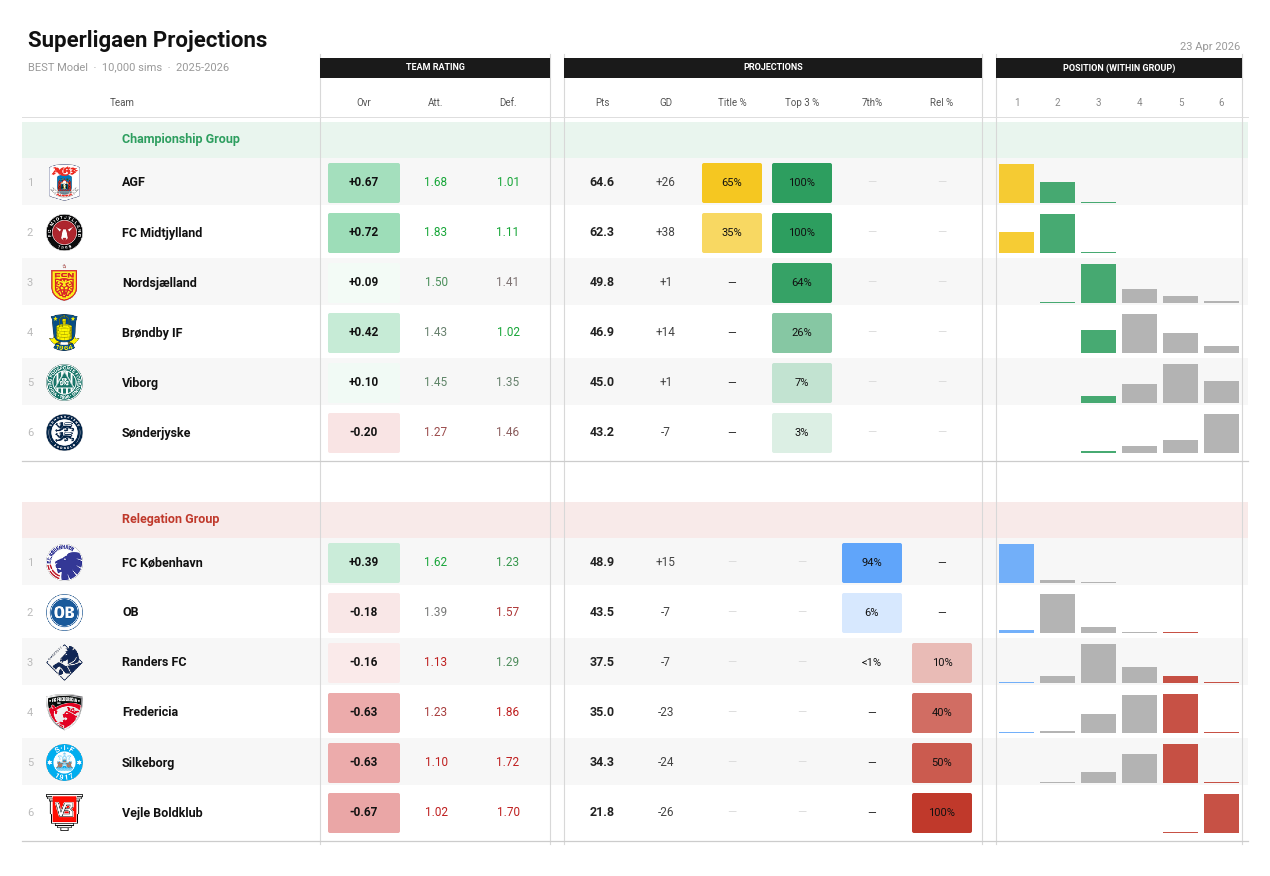

Saved → /Users/admin/dev/algobetting/analysis/superliga-run-in/outputs/superliga_projections.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from io import BytesIO
import requests as _req
from datetime import date
import sys
sys.path.insert(0, str(REPO_ROOT / 'viz'))
from logos import TEAM_LOGOS
from src.simulation import predict_match

for _p in ['/Users/admin/Library/Fonts/Roboto-Regular.ttf',
           '/Users/admin/Library/Fonts/Roboto-Bold.ttf']:
    try: fm.fontManager.addfont(_p)
    except: pass
plt.rcParams['font.family'] = 'Roboto'

OUT_DIR = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

_SAVE_DPI = 220
_BADGE_PX = 64

_HDRS = {'User-Agent': 'Mozilla/5.0'}

def _fetch_badge(url):
    try:
        r = _req.get(url, timeout=5, headers=_HDRS)
        img = Image.open(BytesIO(r.content)).convert('RGBA')
        bb = img.getbbox()
        if bb: img = img.crop(bb)
        sc = _BADGE_PX / max(img.width, img.height)
        nw, nh = max(1, round(img.width*sc)), max(1, round(img.height*sc))
        img = img.resize((nw, nh), Image.LANCZOS)
        sq = Image.new('RGBA', (_BADGE_PX, _BADGE_PX), (0,0,0,0))
        sq.paste(img, ((_BADGE_PX-nw)//2, (_BADGE_PX-nh)//2), mask=img)
        return sq
    except Exception:
        return None

print('Fetching badges...')
badge_cache = {}
for team in list(champ_group | rel_group):
    url = TEAM_LOGOS.get(team)
    if url and url not in badge_cache:
        badge_cache[url] = _fetch_badge(url)
print(f'  {sum(v is not None for v in badge_cache.values())}/{len(badge_cache)} loaded')

# ── within-group position simulation ──────────────────────────────────────────
def _group_pos_sim(ordered_teams, group_fixtures, n_sims=N_SIMS):
    n = len(ordered_teams)
    team_idx_map = {t: i for i, t in enumerate(ordered_teams)}
    fix_xg = []
    for f in group_fixtures:
        h, a = f['home'], f['away']
        if h not in team_mapping or a not in team_mapping:
            continue
        pred = predict_match(h, a, trace, team_mapping)
        fix_xg.append((h, a, pred['home_goals_expected'], pred['away_goals_expected']))
    hxg_arr = np.array([r[2] for r in fix_xg]) if fix_xg else np.array([])
    axg_arr = np.array([r[3] for r in fix_xg]) if fix_xg else np.array([])
    counts = np.zeros((n, n), dtype=np.int32)
    for _ in range(n_sims):
        pts = [_pts.get(t, 0) for t in ordered_teams]
        gd  = [_gd.get(t, 0)  for t in ordered_teams]
        if fix_xg:
            hg_sim = np.random.poisson(hxg_arr)
            ag_sim = np.random.poisson(axg_arr)
            for i, (ht, at, _, _) in enumerate(fix_xg):
                hi, ai = team_idx_map[ht], team_idx_map[at]
                hg, ag = int(hg_sim[i]), int(ag_sim[i])
                gd[hi] += hg - ag; gd[ai] += ag - hg
                if hg > ag:    pts[hi] += 3
                elif hg == ag: pts[hi] += 1; pts[ai] += 1
                else:          pts[ai] += 3
        order = np.lexsort((gd, pts))[::-1]
        for rank, ti in enumerate(order):
            counts[ti, rank] += 1
    return {t: list(counts[i]) for i, t in enumerate(ordered_teams)}

CHAMP_ORDER = champ_df['team'].tolist()
REL_ORDER   = rel_df['team'].tolist()
champ_fix = [f for f in remaining_fixtures if f['home'] in champ_group]
rel_fix   = [f for f in remaining_fixtures if f['home'] in rel_group]

print('Within-group sims...')
champ_grp_freq = _group_pos_sim(CHAMP_ORDER, champ_fix)
rel_grp_freq   = _group_pos_sim(REL_ORDER,   rel_fix)
print('Done.')

# ── colour helpers ─────────────────────────────────────────────────────────────
def _cell_bg(zone_hex, val, scale=70):
    if val < 0.5: return 'white'
    r, g, b = mcolors.to_rgb(zone_hex)
    t = min(1.0, (val/scale)**0.55)
    return mcolors.to_hex((1+(r-1)*t, 1+(g-1)*t, 1+(b-1)*t))

def _xgd_color(val, vmin=-1.5, vmax=1.5):
    norm = max(0., min(1., (val-vmin)/(vmax-vmin)))
    if norm >= 0.5:
        t = (norm-.5)*2
        return mcolors.to_hex((1-t*.80, 1-t*.28, 1-t*.58))
    else:
        t = (.5-norm)*2
        return mcolors.to_hex((1-t*.18, 1-t*.78, 1-t*.78))

def _stat_color(val, avg, spread, good='high'):
    t = (val-avg)/spread if spread else 0
    if good == 'low': t = -t
    t = max(-1., min(1., t))
    if t >= 0: r,g,b = .47-t*.38, .47+t*.18, .47-.25*t
    else:      s=-t; r,g,b = .47+s*.28, .47-s*.35, .47-s*.35
    return mcolors.to_hex((max(0,r), max(0,g), max(0,b)))

# ── xG lookup ─────────────────────────────────────────────────────────────────
xg_lkp = xg_table.set_index('team')
all_xgf = [(xg_lkp.loc[t,'xg_home_for']+xg_lkp.loc[t,'xg_away_for'])/2 for t in xg_lkp.index]
all_xga = [(xg_lkp.loc[t,'xg_home_ag'] +xg_lkp.loc[t,'xg_away_ag']) /2 for t in xg_lkp.index]
avg_xgf, avg_xga = float(np.mean(all_xgf)), float(np.mean(all_xga))
spread_xg = max(float(np.std(all_xgf)), 0.1)

def _xg_vals(team):
    xgf = (xg_lkp.loc[team,'xg_home_for']+xg_lkp.loc[team,'xg_away_for'])/2
    xga = (xg_lkp.loc[team,'xg_home_ag'] +xg_lkp.loc[team,'xg_away_ag']) /2
    return round(xgf,2), round(xga,2), round(xgf-xga,2)

# ── data rows ─────────────────────────────────────────────────────────────────
def _build_row(team, group):
    r = avg_table[avg_table['team']==team].iloc[0]
    xgf, xga, xgd = _xg_vals(team)
    if group == 'champ':
        gfreq     = champ_grp_freq[team]
        title_pct = round(gfreq[0]/N_SIMS*100, 1)
        top3_pct  = round(sum(gfreq[0:3])/N_SIMS*100, 1)
        top_pct   = None
        rel_pct   = None
    else:
        gfreq     = rel_grp_freq[team]
        title_pct = None
        top3_pct  = None
        top_pct   = round(gfreq[0]/N_SIMS*100, 1)
        rel_pct   = round(sum(gfreq[4:6])/N_SIMS*100, 1)
    return {
        'team':    team,
        'proj':    round(r['avg_points'], 1),
        'proj_gd': int(round(r['avg_goal_difference'])),
        'xgf': xgf, 'xga': xga, 'xgd': xgd,
        'title': title_pct, 'top3': top3_pct,
        'top': top_pct, 'rel': rel_pct,
        'gfreq': gfreq,
    }

champ_rows = [_build_row(t, 'champ') for t in CHAMP_ORDER]
rel_rows   = [_build_row(t, 'rel')   for t in REL_ORDER]

# ── layout ─────────────────────────────────────────────────────────────────────
ROW_H     = 0.50
GRP_HDR_H = 0.36
GAP_H     = 0.44
PAD_TOP   = 1.12
PAD_BOT   = 0.28
FIG_W     = 12.5
N_CHAMP, N_REL = len(champ_rows), len(rel_rows)
FIG_H = (N_CHAMP+N_REL)*ROW_H + 2*GRP_HDR_H + GAP_H + PAD_TOP + PAD_BOT

X_RANK  = 0.20;  X_BADGE = 0.54;  X_NAME  = 1.12

# TEAM RATING: Ovr (xGD pill) → Att. (xGF) → Def. (xGA)
SEC1_L=3.10; X_OVR=3.54; X_ATT=4.26; X_DEF=4.98; SEC1_R=5.40

# PROJECTIONS: Pts · GD · Title% · Top 3% · 7th% · Rel%
SEC2_L=5.54; X_PROJ=5.92; X_GD=6.56; X_TITLE=7.22; X_TOP3=7.92; X_TOP=8.62; X_REL=9.32; SEC2_R=9.72

X_BAR_L=9.86; X_BAR_R=FIG_W-0.18; BAR_W=X_BAR_R-X_BAR_L; SLOT_W=BAR_W/6

CHAMP_BAR_C = ['#F5C518', '#2d9e5f', '#2d9e5f', '#aaaaaa', '#aaaaaa', '#aaaaaa']
REL_BAR_C   = ['#60A5FA', '#aaaaaa', '#aaaaaa', '#aaaaaa', '#c0392b', '#c0392b']

# ── figure ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('white')
ax = fig.add_axes([0,0,1,1])
ax.set_xlim(0,FIG_W); ax.set_ylim(0,FIG_H); ax.axis('off')

ax.text(0.18, FIG_H-.20, 'Superligaen Projections',
        fontsize=16, fontweight='bold', color='#111', va='top')
ax.text(0.18, FIG_H-.52,
        f'BEST Model  ·  {N_SIMS:,} sims  ·  2025-2026',
        fontsize=8, color='#999', va='top')
ax.text(FIG_W-.20, FIG_H-.32, date.today().strftime('%-d %b %Y'),
        fontsize=8, color='#999', va='top', ha='right')

sec_bar_y = FIG_H - PAD_TOP + 0.44; sec_bar_h = 0.20
for lx, rx, lbl in [(SEC1_L, SEC1_R, 'TEAM RATING'),
                     (SEC2_L, SEC2_R, 'PROJECTIONS'),
                     (X_BAR_L, X_BAR_R, 'POSITION (WITHIN GROUP)')]:
    ax.add_patch(mpatches.Rectangle((lx,sec_bar_y),rx-lx,sec_bar_h,
                                     facecolor='#1a1a1a',edgecolor='none',zorder=2))
    ax.text((lx+rx)/2, sec_bar_y+sec_bar_h/2, lbl,
            fontsize=6.5, fontweight='bold', color='white', va='center', ha='center', zorder=3)

hdr_y = FIG_H-PAD_TOP+0.19
for x, lbl in [(X_NAME,'Team'), (X_OVR,'Ovr'), (X_ATT,'Att.'), (X_DEF,'Def.'),
               (X_PROJ,'Pts'), (X_GD,'GD'),
               (X_TITLE,'Title %'), (X_TOP3,'Top 3 %'), (X_TOP,'7th%'), (X_REL,'Rel %')]:
    ax.text(x, hdr_y, lbl, fontsize=7, color='#555', va='center', ha='center')
for i in range(6):
    ax.text(X_BAR_L+i*SLOT_W+SLOT_W/2, hdr_y, str(i+1),
            fontsize=7, color='#888', va='center', ha='center')
ax.plot([0.12,FIG_W-.12],[hdr_y-.14]*2, color='#ddd', lw=0.7)

vline_top = sec_bar_y+sec_bar_h+.04; vline_bot = PAD_BOT-.06
for vx in [SEC1_L, SEC1_R, SEC2_L, SEC2_R, X_BAR_L, X_BAR_R]:
    ax.plot([vx,vx],[vline_bot,vline_top], color='#d8d8d8', lw=0.8, zorder=1)

# ── draw group ─────────────────────────────────────────────────────────────────
def draw_group(rows, y_bottom, label, label_color, bar_colors):
    hdr_bot = y_bottom + len(rows)*ROW_H
    ax.add_patch(mpatches.Rectangle((0.12,hdr_bot),FIG_W-.24,GRP_HDR_H,
                                     facecolor=label_color,alpha=0.10,edgecolor='none',zorder=0))
    ax.text(X_NAME, hdr_bot+GRP_HDR_H/2, label,
            fontsize=9, fontweight='bold', color=label_color, va='center', ha='left', zorder=2)

    for i, d in enumerate(rows):
        row_bot = y_bottom + (len(rows)-1-i)*ROW_H
        row_mid = row_bot + ROW_H/2

        ax.add_patch(mpatches.Rectangle((0.12,row_bot+.03),FIG_W-.24,ROW_H-.03,
                                         facecolor='#f7f7f7' if i%2==0 else 'white',
                                         edgecolor='none',zorder=0))

        ax.text(X_RANK, row_mid, str(i+1), fontsize=8, va='center', ha='center', color='#bbb')

        url = TEAM_LOGOS.get(d['team'])
        if url and badge_cache.get(url) is not None:
            im = OffsetImage(badge_cache[url], zoom=90/_SAVE_DPI)
            ax.add_artist(AnnotationBbox(im,(X_BADGE,row_mid),frameon=False,zorder=3))

        ax.text(X_NAME, row_mid, d['team'], fontsize=9, fontweight='bold',
                va='center', ha='left', color='#111')

        # Ovr pill (xGD) — bold, +.2f
        ax.add_patch(mpatches.FancyBboxPatch(
            (X_OVR-.34, row_mid-ROW_H*.36), .68, ROW_H*.72,
            boxstyle='round,pad=0.02', facecolor=_xgd_color(d['xgd']),
            edgecolor='none', zorder=1))
        ax.text(X_OVR, row_mid, f"{d['xgd']:+.2f}", fontsize=8.5, fontweight='bold',
                va='center', ha='center', color='#111')

        # Att. (xGF) and Def. (xGA)
        ax.text(X_ATT, row_mid, f"{d['xgf']:.2f}", fontsize=8.5, va='center', ha='center',
                color=_stat_color(d['xgf'],avg_xgf,spread_xg,'high'))
        ax.text(X_DEF, row_mid, f"{d['xga']:.2f}", fontsize=8.5, va='center', ha='center',
                color=_stat_color(d['xga'],avg_xga,spread_xg,'low'))

        # Projected points — bold
        ax.text(X_PROJ, row_mid, f"{d['proj']:.1f}", fontsize=9, fontweight='bold',
                va='center', ha='center', color='#222')

        # Projected GD — plain
        ax.text(X_GD, row_mid, f"{d['proj_gd']:+d}", fontsize=8.5,
                va='center', ha='center', color='#444')

        # projection %s
        for x, val, zc in [(X_TITLE,d['title'],'#F5C518'),
                            (X_TOP3, d['top3'], '#2d9e5f'),
                            (X_TOP,  d['top'],  '#60A5FA'),
                            (X_REL,  d['rel'],  '#c0392b')]:
            if val is None:
                ax.text(x, row_mid, '—', fontsize=8.5, va='center', ha='center', color='#ddd')
            else:
                bg = _cell_bg(zc, val)
                if bg != 'white':
                    ax.add_patch(mpatches.FancyBboxPatch(
                        (x-.28, row_mid-ROW_H*.36), .56, ROW_H*.72,
                        boxstyle='round,pad=0.02', facecolor=bg,
                        edgecolor='none', zorder=1))
                lbl = f'{val:.0f}%' if val >= 1 else ('<1%' if val > 0 else '—')
                ax.text(x, row_mid, lbl, fontsize=8, va='center', ha='center', color='#111')

        # position bars
        probs  = [c/N_SIMS for c in d['gfreq']]
        max_p  = max(probs) if max(probs) > 0 else 1
        bmax_h = ROW_H * 0.78
        bbot   = row_mid - bmax_h/2
        bw     = SLOT_W * 0.86
        for pi, prob in enumerate(probs):
            bh = (prob/max_p)*bmax_h
            bx = X_BAR_L + pi*SLOT_W + SLOT_W*0.07
            ax.add_patch(mpatches.Rectangle(
                (bx, bbot), bw, bh,
                facecolor=bar_colors[pi], edgecolor='none', zorder=1, alpha=0.88))

    ax.plot([0.12,FIG_W-.12],[y_bottom-.03]*2, color='#ccc', lw=0.9)

rel_y   = PAD_BOT
champ_y = PAD_BOT + N_REL*ROW_H + GRP_HDR_H + GAP_H

draw_group(rel_rows,   rel_y,   'Relegation Group',   '#c0392b', REL_BAR_C)
draw_group(champ_rows, champ_y, 'Championship Group', '#2d9e5f', CHAMP_BAR_C)

save_path = str(OUT_DIR / 'superliga_projections.png')
plt.savefig(save_path, dpi=_SAVE_DPI, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {save_path}')

## AGF vs FC Midtjylland — xP from remaining fixtures

In [14]:
_FOCUS = ['AGF', 'FC Midtjylland']

rows = []
for f in remaining_fixtures:
    h, a = f['home'], f['away']
    if h not in _FOCUS and a not in _FOCUS:
        continue
    if h not in team_mapping or a not in team_mapping:
        continue
    hl, al  = _predict(h, a)
    w, d, l = _match_probs(hl, al)

    for team in _FOCUS:
        if team not in (h, a):
            continue
        is_home = (team == h)
        win_p   = w if is_home else l
        loss_p  = l if is_home else w
        xp      = round(3 * win_p + d, 3)
        rows.append({
            'Team':     team,
            'GW':       f['gw'],
            'Date':     f['date'],
            'Venue':    'H' if is_home else 'A',
            'Opponent': a if is_home else h,
            'xG For':   round(hl if is_home else al, 2),
            'xG Ag':    round(al if is_home else hl, 2),
            'W%':       round(win_p  * 100, 1),
            'D%':       round(d      * 100, 1),
            'L%':       round(loss_p * 100, 1),
            'xP':       xp,
        })

xp_df = pd.DataFrame(rows).sort_values(['Team', 'Date']).reset_index(drop=True)

for team in _FOCUS:
    t_df     = xp_df[xp_df['Team'] == team].reset_index(drop=True)
    cur_pts  = pts_map.get(team, 0)
    total_xp = round(t_df['xP'].sum(), 1)
    print(f"{'─'*58}")
    print(f"  {team}  |  current: {cur_pts} pts  |  xP remaining: {total_xp}  |  projected: {cur_pts + total_xp:.1f}")
    print(f"{'─'*58}")
    display(t_df.drop(columns='Team'))
    print()

──────────────────────────────────────────────────────────
  AGF  |  current: 56 pts  |  xP remaining: 8.6  |  projected: 64.6
──────────────────────────────────────────────────────────


,GW,Date,Venue,Opponent,xG For,xG Ag,W%,D%,L%,xP
0,28,2026-04-23,A,Nordsjælland,1.75,1.33,47.4,23.4,29.3,1.655
1,29,2026-04-26,H,FC Midtjylland,1.63,1.38,43.5,24.1,32.5,1.544
2,30,2026-05-03,H,Sønderjyske,2.09,0.99,62.8,20.3,16.9,2.086
3,31,2026-05-10,A,Brøndby IF,1.28,1.28,36.7,26.6,36.8,1.366
4,32,2026-05-17,H,Viborg,1.93,1.12,56.2,22.0,21.7,1.907



──────────────────────────────────────────────────────────
  FC Midtjylland  |  current: 54 pts  |  xP remaining: 8.2  |  projected: 62.2
──────────────────────────────────────────────────────────


,GW,Date,Venue,Opponent,xG For,xG Ag,W%,D%,L%,xP
0,28,2026-04-23,A,Sønderjyske,1.97,1.26,53.9,21.9,24.3,1.835
1,29,2026-04-26,A,AGF,1.38,1.63,32.5,24.1,43.5,1.215
2,30,2026-05-04,H,Viborg,2.08,1.23,56.8,21.0,22.2,1.914
3,31,2026-05-10,A,Nordsjælland,1.89,1.46,47.7,22.3,30.0,1.653
4,32,2026-05-17,H,Brøndby IF,1.59,1.22,45.8,24.8,29.5,1.621


In [15]:
# Datawrapper-style export
_T1, _T2 = 'AGF', 'FC Midtjylland'
_t1 = xp_df[xp_df['Team'] == _T1].set_index('GW')
_t2 = xp_df[xp_df['Team'] == _T2].set_index('GW')

gws = sorted(set(_t1.index) | set(_t2.index))
dw_rows = []
for gw in gws:
    r1 = _t1.loc[gw] if gw in _t1.index else None
    r2 = _t2.loc[gw] if gw in _t2.index else None
    date = r1['Date'] if r1 is not None else r2['Date']
    dw_rows.append({
        'GW':          gw,
        'Date':        date,
        f'{_T1} game': f"{'H' if r1['Venue']=='H' else 'A'} {r1['Opponent']}" if r1 is not None else '',
        f'{_T1} xP':   r1['xP'] if r1 is not None else '',
        f'{_T2} game': f"{'H' if r2['Venue']=='H' else 'A'} {r2['Opponent']}" if r2 is not None else '',
        f'{_T2} xP':   r2['xP'] if r2 is not None else '',
    })

dw_df = pd.DataFrame(dw_rows)

_t1_cur = pts_map.get(_T1, 0)
_t2_cur = pts_map.get(_T2, 0)
_t1_xp  = round(xp_df[xp_df['Team']==_T1]['xP'].sum(), 1)
_t2_xp  = round(xp_df[xp_df['Team']==_T2]['xP'].sum(), 1)
dw_df.loc[len(dw_df)] = {
    'GW': 'Projected',
    'Date': '',
    f'{_T1} game': f'Current: {_t1_cur} pts',
    f'{_T1} xP':   round(_t1_cur + _t1_xp, 1),
    f'{_T2} game': f'Current: {_t2_cur} pts',
    f'{_T2} xP':   round(_t2_cur + _t2_xp, 1),
}

print(dw_df.to_csv(index=False))

GW,Date,AGF game,AGF xP,FC Midtjylland game,FC Midtjylland xP
28,2026-04-23,A Nordsjælland,1.655,A Sønderjyske,1.835
29,2026-04-26,H FC Midtjylland,1.544,A AGF,1.215
30,2026-05-03,H Sønderjyske,2.086,H Viborg,1.914
31,2026-05-10,A Brøndby IF,1.366,A Nordsjælland,1.653
32,2026-05-17,H Viborg,1.907,H Brøndby IF,1.621
Projected,,Current: 56 pts,64.6,Current: 54 pts,62.2

